<a href="https://colab.research.google.com/github/leandrom88/tesis-restauracion-imagenes/blob/main/Tesina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Montaje de Entorno y Definición de Rutas**

Explicación: Conectamos Google Colab con tu almacenamiento de Google Drive para acceder al subconjunto de imágenes limpias de CMP Facades (~115 imágenes) y preparamos la carpeta de salida donde se guardará el conjunto sintético aumentado.

In [ ]:
# ==============================================================================
# CELDA 1: CONFIGURACIÓN DEL ENTORNO Y RUTAS DE TRABAJO
# ==============================================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definición de rutas directas en Drive
RUTA_LIMPIAS = '/content/drive/MyDrive/Imagenes Limpias'
RUTA_SINTETICAS = '/content/drive/MyDrive/edificios-degradados-sinteticos'

# 3. Crear carpeta de salida si no existe
if not os.path.exists(RUTA_SINTETICAS):
    os.makedirs(RUTA_SINTETICAS)
    print(f"✅ Carpeta de salida creada: {RUTA_SINTETICAS}")
else:
    print(f"ℹ️ Carpeta de salida disponible: {RUTA_SINTETICAS}")

# 4. Validar disponibilidad de las imágenes limpias
if os.path.exists(RUTA_LIMPIAS):
    extensiones = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    archivos_limpios = [f for f in os.listdir(RUTA_LIMPIAS) if f.lower().endswith(extensiones)]
    print(f"✅ Se encontraron {len(archivos_limpios)} imágenes limpias para procesar.")
else:
    print(f"⚠️ No se encontró la carpeta en: {RUTA_LIMPIAS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ℹ️ Carpeta de salida disponible: /content/drive/MyDrive/edificios-degradados-sinteticos
✅ Se encontraron 115 imágenes limpias para procesar.


**Funciones Modulares de Degradación con Variantes (Parámetros Dinámicos)**

Explicación: Definimos una función en Python por cada degradación real acordada con los tutores. Cada función acepta parámetros para variaciones de tamaño, ubicación $(X, Y)$, intensidad y opacidad, asegurando que ninguna imagen modificada sea idéntica a otra.

In [ ]:
# 4. CAPTURA DE PANTALLA DE ESCRITORIO (Visor de fotos con controles visibles en borde inferior)
def simular_captura_pantalla_escritorio(imagen):
    alto, ancho, _ = imagen.shape
    resultado = imagen.copy()

    # Dimensiones de la barra de controles flotante
    alto_barra = max(24, int(alto * 0.05))
    ancho_barra = max(180, int(ancho * 0.35))
    x_inicio = int((ancho - ancho_barra) / 2)
    y_inicio = alto - alto_barra - 15

    # Overlay semitransparente oscuro para la barra
    overlay = resultado.copy()
    cv2.rectangle(overlay, (x_inicio, y_inicio), (x_inicio + ancho_barra, y_inicio + alto_barra), (30, 30, 30), -1)
    cv2.rectangle(overlay, (x_inicio, y_inicio), (x_inicio + ancho_barra, y_inicio + alto_barra), (100, 100, 100), 1)

    # Texto de los controles (-  100%  +)
    escala = max(0.4, min(alto, ancho) * 0.0007)
    cv2.putText(overlay, "-   100%   +", (x_inicio + 20, y_inicio + int(alto_barra * 0.68)),
                cv2.FONT_HERSHEY_SIMPLEX, escala, (230, 230, 230), 1, cv2.LINE_AA)

    return cv2.addWeighted(resultado, 0.3, overlay, 0.7, 0)

# 5. PÉRDIDA DE NITIDEZ / DESENFOQUE GLOBAL CON SUAVIZADO ALEATORIO
def aplicar_perdida_nitidez(imagen, kernel_size=None):
    """
    Aplica desenfoque Gaussiano global sobre toda la imagen.
    Selecciona aleatoriamente la intensidad del suavizado (desde sutil hasta severo).
    """
    if kernel_size is None:
        # Selección aleatoria de la intensidad del suavizado
        kernel_size = np.random.choice([3, 5, 7, 9])

    if kernel_size % 2 == 0:
        kernel_size += 1

    sigma = np.random.uniform(0.8, 2.5) # Varianza estocástica de desenfoque
    return cv2.GaussianBlur(imagen, (kernel_size, kernel_size), sigmaX=sigma)

**Muestra de Prueba y Control Visual**

Explicación: Ejecutamos una comprobación visual previa sobre una imagen limpia para corroborar que la aplicación de las funciones modulares produzca resultados nítidos y coherentes antes de procesar el lote completo.

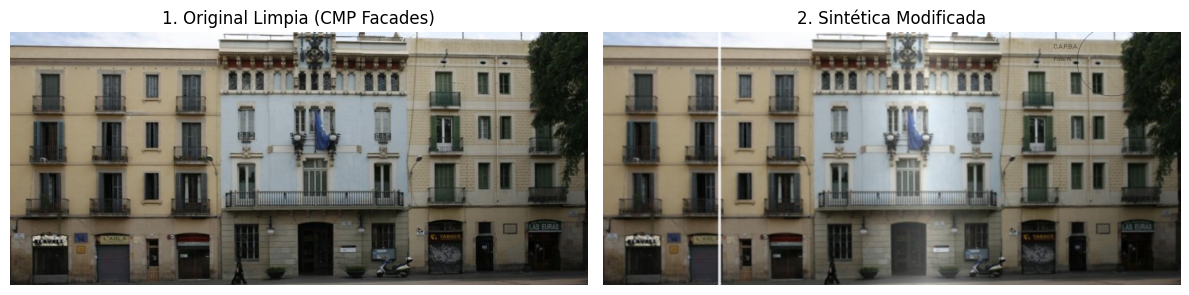

In [ ]:
# ==============================================================================
# CELDA 3: CONTROL VISUAL PREVIO
# ==============================================================================

if os.path.exists(RUTA_LIMPIAS) and len(archivos_limpios) > 0:
    ruta_test = os.path.join(RUTA_LIMPIAS, archivos_limpios[0])
    img_test = cv2.imread(ruta_test)

    # Cadena de degradaciones de prueba
    img_deg = simular_linea_brillante_escaneo(img_test)
    img_deg = simular_exceso_luz_solar(img_deg)
    img_deg = aplicar_perdida_nitidez(img_deg)
    img_deg = simular_sello_administrativo(img_deg)

    fig, subplots = plt.subplots(1, 2, figsize=(12, 6))
    subplots[0].imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
    subplots[0].set_title("1. Original Limpia (CMP Facades)")
    subplots[0].axis('off')

    subplots[1].imshow(cv2.cvtColor(img_deg, cv2.COLOR_BGR2RGB))
    subplots[1].set_title("2. Sintética Modificada")
    subplots[1].axis('off')

    plt.tight_layout()
    plt.show()

**Procesamiento Masivo Combinatorio y Registro de Trazabilidad (CSV)**

Explicación: Procesamos el subconjunto completo de imágenes limpias aplicando las degradaciones con parámetros dinámicos de forma masiva. Cada archivo generado conserva el ID original mediante el prefijo degradada_ y se exporta una tabla .csv en Google Drive con la correspondencia exacta para medir la calidad de restauración en los modelos generativos.

In [ ]:
# ==============================================================================
# CELDA 4: PROCESAMIENTO EN LOTE CON LECTURA DIRECTA DEL SHEETS
# ==============================================================================

if os.path.exists(RUTA_LIMPIAS) and len(archivos_limpios) > 0:
    print(f"🚀 Procesando {len(archivos_limpios)} imágenes del dataset limpio...")

    registro_trazabilidad = []
    contador = 0

    for archivo in archivos_limpios:
        ruta_entrada = os.path.join(RUTA_LIMPIAS, archivo)
        img_matriz = cv2.imread(ruta_entrada)

        if img_matriz is not None:
            degradaciones_aplicadas = []

            # 1. Línea brillante por escaneo
            img_proc = simular_linea_brillante_escaneo(img_matriz)
            degradaciones_aplicadas.append("Línea brillante por escaneo")

            # 2. Pérdida de nitidez / Desenfoque global (Captura 5)
            img_proc = aplicar_perdida_nitidez(img_proc)
            degradaciones_aplicadas.append("Pérdida de nitidez (Desenfoque)")

            # 3. Destello de luz solar (Captura 1)
            if np.random.rand() < 0.6:
                img_proc = simular_destello_luz_solar(img_proc)
                degradaciones_aplicadas.append("Destello de luz solar")

            # 4. Destello de lente / Lens flare (Captura 2)
            if np.random.rand() < 0.4:
                img_proc = simular_destello_lente(img_proc)
                degradaciones_aplicadas.append("Destello de lente")

            # 5. Captura de pantalla de escritorio (Captura 3)
            if np.random.rand() < 0.2:
                img_proc = simular_captura_pantalla_escritorio(img_proc)
                degradaciones_aplicadas.append("Captura de pantalla de escritorio")

            # 6. Exceso de luz solar / Sobreexposición
            if np.random.rand() < 0.5:
                img_proc = simular_exceso_luz_solar(img_proc)
                degradaciones_aplicadas.append("Exceso de luz solar")

            # 7. Sello administrativo y marca 'F' (Capturas 4 y 5)
            if np.random.rand() < 0.8:
                img_proc = simular_sello_administrativo(img_proc)
                degradaciones_aplicadas.append("Sello administrativo")

            # 8. Sombras oscuras en fachada
            if np.random.rand() < 0.4:
                img_proc = simular_sombras_oscuras(img_proc)
                degradaciones_aplicadas.append("Sombras oscuras en fachada")

            # 9. Manchas de color
            if np.random.rand() < 0.3:
                img_proc = simular_mancha_color(img_proc)
                degradaciones_aplicadas.append("Mancha de color")

            # Guardar versión degradada para trazabilidad
            nombre_salida = f"degradada_{archivo}"
            ruta_salida = os.path.join(RUTA_SINTETICAS, nombre_salida)
            cv2.imwrite(ruta_salida, img_proc)

            registro_trazabilidad.append({
                "Imagen_Original_Target": archivo,
                "Imagen_Sintetica_Input": nombre_salida,
                "Cantidad_Degradaciones": len(degradaciones_aplicadas),
                "Detalle_Degradaciones": ", ".join(degradaciones_aplicadas)
            })

            contador += 1
            if contador % 10 == 0 or contador == len(archivos_limpios):
                print(f"Progreso: {contador}/{len(archivos_limpios)} parejas generadas.")

    # Guardar archivo de trazabilidad CSV
    df_trazabilidad = pd.DataFrame(registro_trazabilidad)
    ruta_csv = os.path.join(RUTA_SINTETICAS, 'registro_degradaciones_sinteticas.csv')
    df_trazabilidad.to_csv(ruta_csv, index=False)

    print("\n🎉 ¡DATASET SINTÉTICO Y ARCHIVO DE TRAZABILIDAD GENERADOS CON ÉXITO!")
    print(f"📁 Parejas guardadas en: {RUTA_SINTETICAS}")
    print(f"📊 Reporte guardado en: {ruta_csv}")
    display(df_trazabilidad.head())

🚀 Procesando 115 imágenes del dataset limpio...
Progreso: 10/115 parejas generadas.
Progreso: 20/115 parejas generadas.
Progreso: 30/115 parejas generadas.
Progreso: 40/115 parejas generadas.
Progreso: 50/115 parejas generadas.
Progreso: 60/115 parejas generadas.
Progreso: 70/115 parejas generadas.
Progreso: 80/115 parejas generadas.
Progreso: 90/115 parejas generadas.
Progreso: 100/115 parejas generadas.
Progreso: 110/115 parejas generadas.
Progreso: 115/115 parejas generadas.

🎉 ¡DATASET SINTÉTICO Y ARCHIVO DE TRAZABILIDAD GENERADOS CON ÉXITO!
📁 Parejas guardadas en: /content/drive/MyDrive/edificios-degradados-sinteticos
📊 Reporte guardado en: /content/drive/MyDrive/edificios-degradados-sinteticos/registro_degradaciones_sinteticas.csv


,Imagen_Original_Target,Imagen_Sintetica_Input,Cantidad_Degradaciones,Detalle_Degradaciones
0,cmp_b0003.jpg,degradada_cmp_b0003.jpg,6,"Línea brillante por escaneo, Pérdida de nitide..."
1,cmp_b0006.jpg,degradada_cmp_b0006.jpg,5,"Línea brillante por escaneo, Pérdida de nitide..."
2,cmp_b0007.jpg,degradada_cmp_b0007.jpg,5,"Línea brillante por escaneo, Pérdida de nitide..."
3,cmp_b0008.jpg,degradada_cmp_b0008.jpg,6,"Línea brillante por escaneo, Pérdida de nitide..."
4,cmp_b0009.jpg,degradada_cmp_b0009.jpg,5,"Línea brillante por escaneo, Pérdida de nitide..."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
